Generando dataset con variaciones...
Entrenamiento completado. Accuracy final: 100.0%


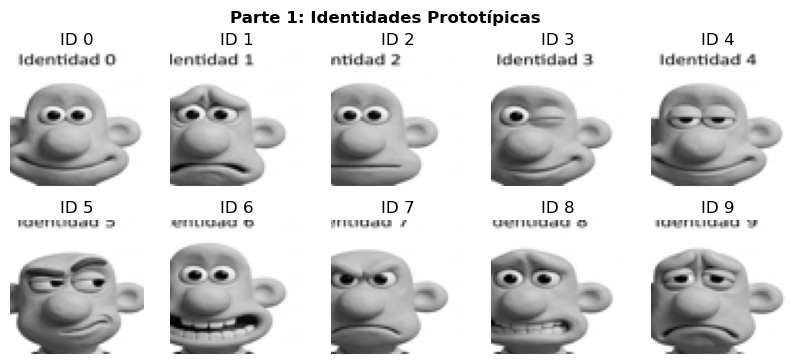

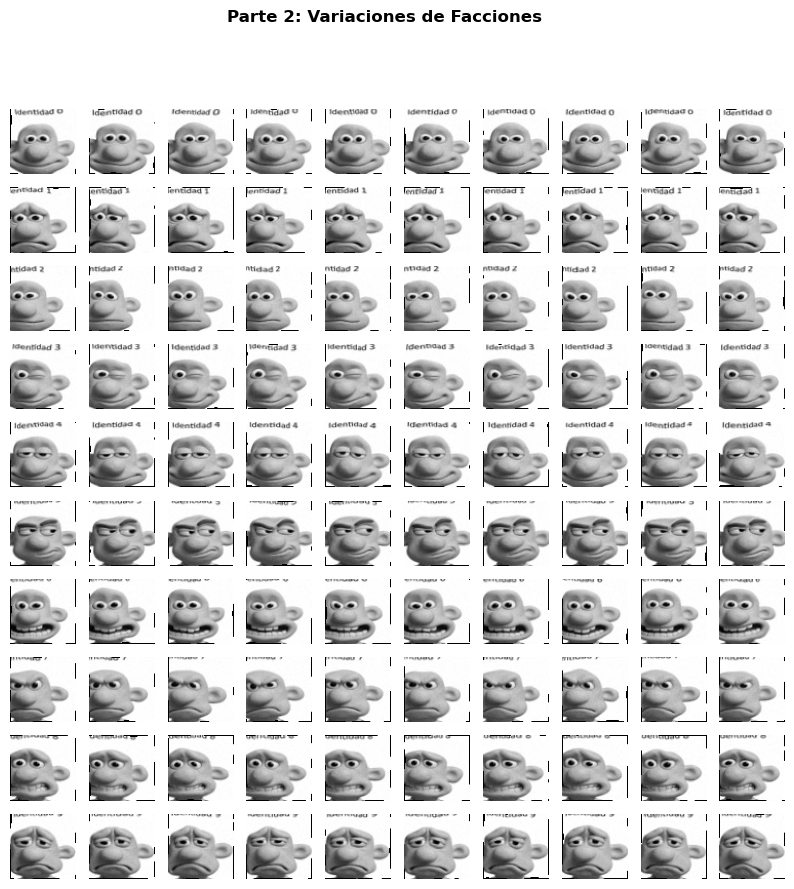

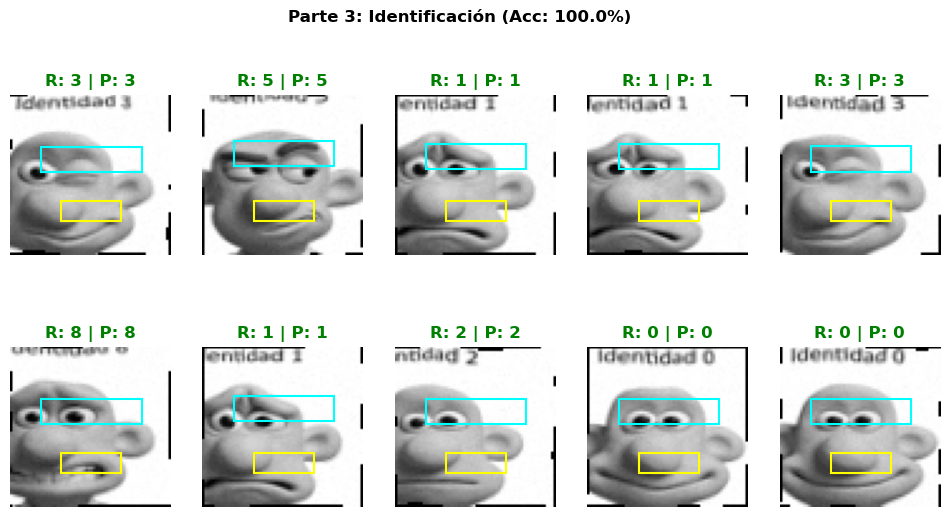

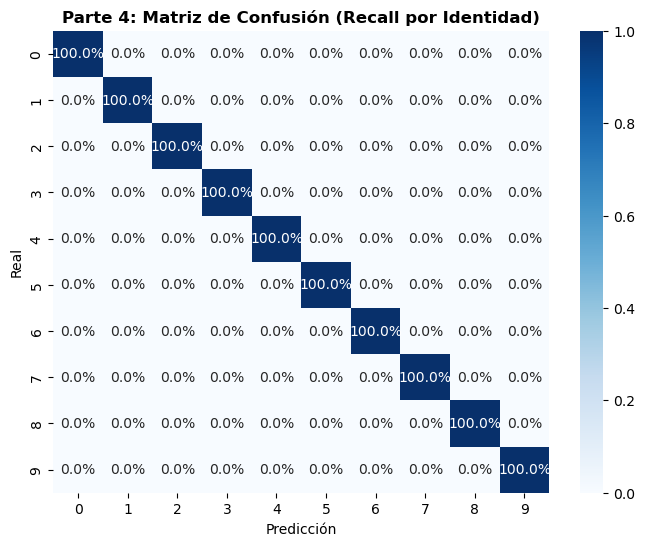

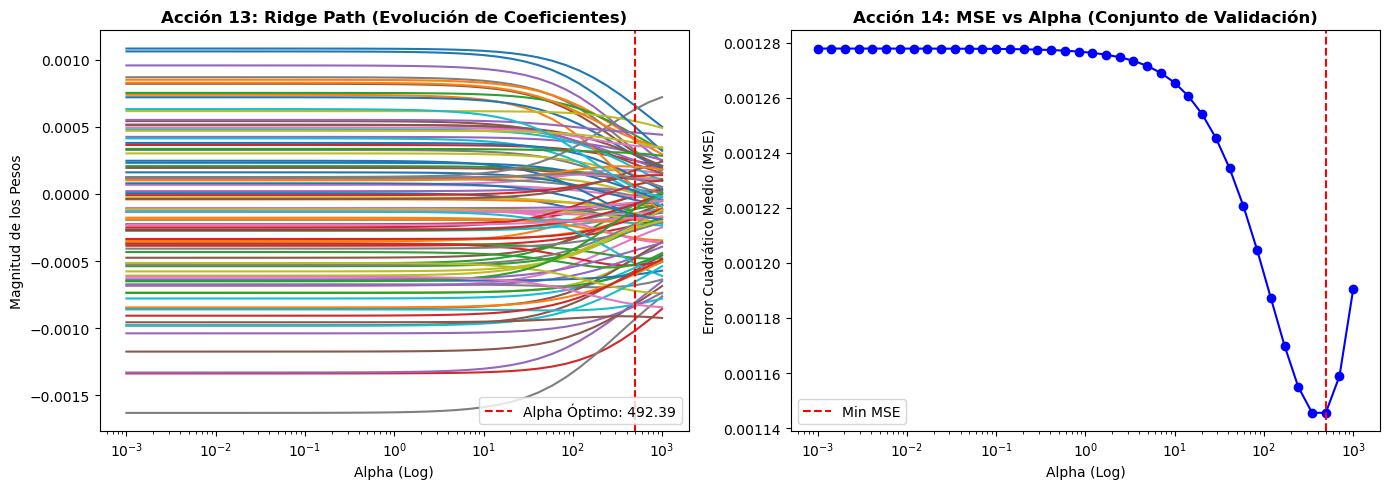

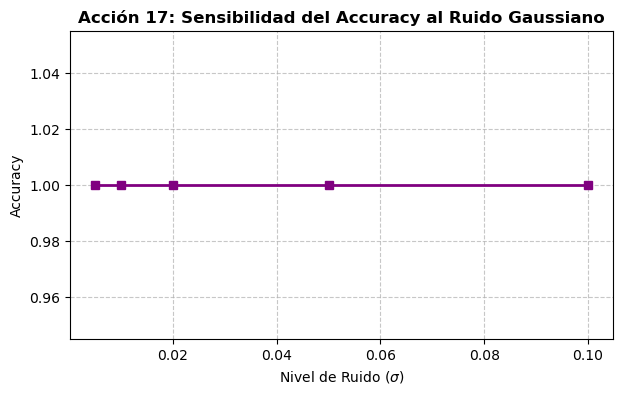

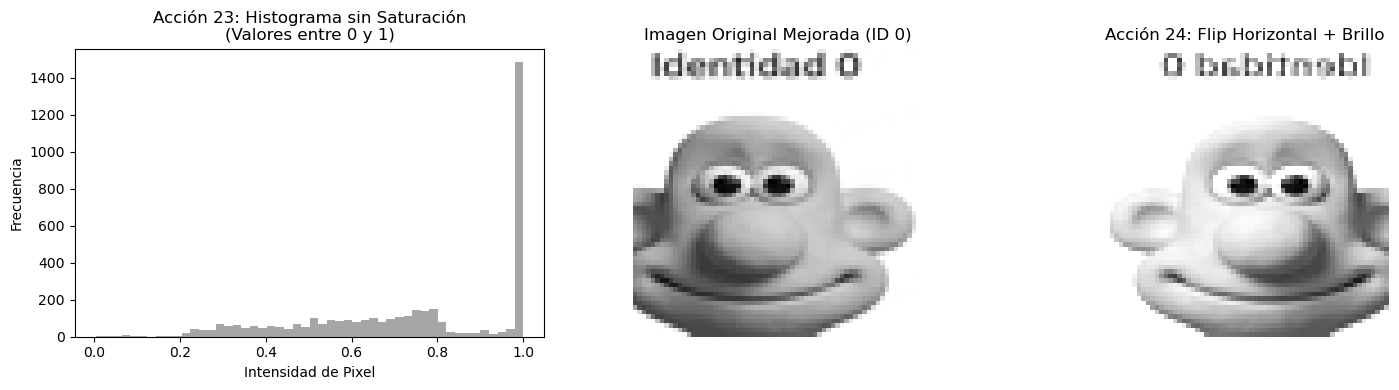

In [7]:
"""
================================================================================
RETO RIDGE REGRESSION - DREAMTEAM 
Versión Final Corregida: Símplex R9 + Distancia Mínima + 80/20 + Experimentos
================================================================================
"""
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.ndimage import gaussian_filter, map_coordinates
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# --- CONFIGURACIÓN ---
RNG = np.random.default_rng(42)
IMG_SIZE = 64          
N_IDENTIDADES = 10     
N_COLUMNAS = 5         
N_POR_IDENTIDAD = 100  

# Parámetros geométricos base
PARAM_BASE = np.array([
    [0.2, 0.5, -0.2, 0.4], [0.3, 0.6, -0.3, 0.3], [0.2, 0.5, -0.2, 0.2], 
    [0.2, 0.1, -0.2, 0.5], [0.2, 0.3, -0.2, 0.4], [0.4, 0.5, -0.1, 0.4], 
    [0.2, 0.6, -0.3, 0.6], [0.1, 0.4, -0.2, 0.5], [0.2, 0.5, -0.3, 0.5], 
    [0.2, 0.4, -0.4, 0.3]
])

# ==============================================================================
# FUNCIONES PRINCIPALES
# ==============================================================================

def generar_simplex(n_clases):
    """
    CORRECCIÓN ACCIÓN 12: Genera los vértices de un símplex regular en R^(n-1).
    Usa SVD sobre una matriz One-Hot centrada para encontrar 10 vértices en R^9.
    """
    I = np.eye(n_clases)
    I_centrada = I - np.mean(I, axis=0)
    U, S, Vt = np.linalg.svd(I_centrada)
    vertices = U[:, :n_clases-1] * S[:n_clases-1]
    return vertices

VERTICES_SIMPLEX = generar_simplex(N_IDENTIDADES)

def ridge_manual(X, y, alpha):
    """Implementación manual de Ridge Regression usando la ecuación normal."""
    n_features = X.shape[1]
    I = np.eye(n_features)
    # Resolución de (X'X + alpha*I) * beta = X'y
    beta = np.linalg.solve(X.T @ X + alpha * I, X.T @ y)
    return beta

def elastic_transform(image, alpha, sigma):
    """Aplica deformación elástica para aumento de datos."""
    shape = image.shape
    dx = gaussian_filter((RNG.random(shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dy = gaussian_filter((RNG.random(shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    x, y = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing='ij')
    indices = np.reshape(x+dx, (-1, 1)), np.reshape(y+dy, (-1, 1))
    return map_coordinates(image, indices, order=1).reshape(shape)

def cargar_y_cortar(ruta_img):
    """Carga la imagen, recorta las 10 identidades aislando el centro facial."""
    try:
        full_img = Image.open(ruta_img).convert('L')
        ancho_c, alto_c = full_img.size[0] // N_COLUMNAS, full_img.size[1] // 2
        prototipos = []
        for i in range(N_IDENTIDADES):
            fila, col = i // N_COLUMNAS, i % N_COLUMNAS
            izq, top = (col * ancho_c) + int(ancho_c * 0.03), fila * alto_c
            celda = full_img.crop((izq, top, izq + ancho_c, top + alto_c))
            
            # CORRECCIÓN ACCIÓN 22: Recorte más estricto emulando landmarks
            margen_x = int(celda.size[0] * 0.15)
            margen_y = int(celda.size[1] * 0.20)
            cara = celda.crop((margen_x, margen_y, celda.size[0] - margen_x, int(celda.size[1] - margen_y * 0.5)))
            
            prototipos.append(np.array(cara.resize((IMG_SIZE, IMG_SIZE))) / 255.0)
        return prototipos
    except Exception as e: 
        print(f"Error cargando la imagen: {e}")
        return None

# ==============================================================================
# PROCESAMIENTO Y PIPELINE
# ==============================================================================
X_base = cargar_y_cortar('expresiones.png') # Cambiar al nombre de tu archivo

if X_base is not None:
    X, y, P = [], [], []
    muestreo_p2 = []

    print("Generando dataset con variaciones...")
    for ident in range(N_IDENTIDADES):
        temp_v = []
        for j in range(N_POR_IDENTIDAD):
            img_v = elastic_transform(X_base[ident], alpha=IMG_SIZE*0.3, sigma=IMG_SIZE*0.08)
            img_v = np.clip(img_v + RNG.normal(0, 0.01, img_v.shape), 0, 1)
            X.append(img_v.ravel()); y.append(ident); P.append(PARAM_BASE[ident])
            if j < 10: temp_v.append(img_v)
        muestreo_p2.append(temp_v)
        
    X, y, P = np.array(X), np.array(y), np.array(P)
    
    # CORRECCIÓN ACCIÓN 10: Estandarización y partición estricta 80/20
    X_train, X_test, y_train, y_test, P_train, P_test = train_test_split(
        X, y, P, test_size=0.2, stratify=y, random_state=42
    )
    mu, sigma = X_train.mean(axis=0), X_train.std(axis=0) + 1e-7
    X_train_s = (X_train - mu) / sigma
    X_test_s = (X_test - mu) / sigma

    # CORRECCIÓN ACCIÓN 12: Entrenamiento usando el Símplex en R^9
    y_train_simplex = VERTICES_SIMPLEX[y_train]
    beta_clf = ridge_manual(X_train_s, y_train_simplex, alpha=1.0)
    beta_param = ridge_manual(X_train_s, P_train, alpha=1.0)

    # Predicción del Clasificador mediante DISTANCIA MÍNIMA
    y_pred_raw = X_test_s @ beta_clf
    y_pred = []
    for pred in y_pred_raw:
        distancias = np.linalg.norm(VERTICES_SIMPLEX - pred, axis=1) # Distancia a los 10 vértices
        y_pred.append(np.argmin(distancias)) # Regla de Bayes
    y_pred = np.array(y_pred)
    
    # Predicción de parámetros (cajas)
    p_pred = X_test_s @ beta_param
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Entrenamiento completado. Accuracy final: {acc*100:.1f}%")

    # ==============================================================================
    # GRÁFICAS BASE
    # ==============================================================================
    
    # PARTE 1: Prototipos
    fig1, ax1 = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(ax1.flat):
        ax.imshow(X_base[i], cmap='gray'); ax.axis('off'); ax.set_title(f"ID {i}")
    plt.suptitle("Parte 1: Identidades Prototípicas", fontweight='bold'); plt.show()

    # PARTE 2: Variantes
    fig2, ax2 = plt.subplots(10, 10, figsize=(10, 10))
    for i in range(10):
        for j in range(10):
            ax2[i,j].imshow(muestreo_p2[i][j], cmap='gray'); ax2[i,j].axis('off')
    plt.suptitle("Parte 2: Variaciones de Facciones", fontweight='bold'); plt.show()

    # PARTE 3: Identificación + Extracción
    fig3, ax3 = plt.subplots(2, 5, figsize=(12, 6))
    for i, ax in enumerate(ax3.flat):
        idx = RNG.integers(0, len(X_test))
        ax.imshow(X_test[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        h_ojos = 20 - (p_pred[idx, 0] * 10)
        ax.add_patch(plt.Rectangle((12, h_ojos), 40, 10, fill=False, edgecolor='cyan', lw=1.5))
        ax.add_patch(plt.Rectangle((20, 42), 24, 8, fill=False, edgecolor='yellow', lw=1.5))
        color = 'green' if y_test[idx] == y_pred[idx] else 'red'
        ax.set_title(f"R: {y_test[idx]} | P: {y_pred[idx]}", color=color, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f"Parte 3: Identificación (Acc: {acc*100:.1f}%)", fontweight='bold'); plt.show()

    # PARTE 4: Matriz de Confusión en Porcentajes (Requisito Acción 19)
    cm = confusion_matrix(y_test, y_pred)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_perc, annot=True, fmt='.1%', cmap='Blues')
    plt.title(f"Parte 4: Matriz de Confusión (Recall por Identidad)", fontweight='bold')
    plt.xlabel("Predicción"); plt.ylabel("Real"); plt.show()

    # ==============================================================================
    # EXPERIMENTOS EXTRAS PARA LOS 100 PUNTOS
    # ==============================================================================

    # ------------------------------------------------------------------------------
    # ACCIONES 11, 13 y 14: BARRIDO DE ALPHAS, RIDGE PATH Y MSE (Con Símplex)
    # ------------------------------------------------------------------------------
    alphas = np.logspace(-3, 3, 40)
    coefs = []
    mses = []

    X_t, X_v, y_t_simp, y_v_simp = train_test_split(X_train_s, y_train_simplex, test_size=0.2, random_state=42)

    for a in alphas:
        I_t = np.eye(X_t.shape[1])
        b = np.linalg.solve(X_t.T @ X_t + a * I_t, X_t.T @ y_t_simp)
        coefs.append(b)
        pred_v = X_v @ b
        mses.append(np.mean((y_v_simp - pred_v)**2))

    coefs = np.array(coefs)
    alpha_optimo = alphas[np.argmin(mses)]

    fig_alpha, (ax_alpha1, ax_alpha2) = plt.subplots(1, 2, figsize=(14, 5))

    # SOLUCIÓN AL ERROR DE DIMENSIONES: Adaptación dinámica según forma del arreglo
    if coefs.ndim == 3:
        ax_alpha1.plot(alphas, coefs[:, :100, 0]) # Grafica la 1ra dimensión del símplex si es 3D
    else:
        ax_alpha1.plot(alphas, coefs[:, :100]) # Grafica normal si la matriz es 2D en memoria

    ax_alpha1.set_xscale('log')
    ax_alpha1.axvline(alpha_optimo, color='r', linestyle='--', label=f'Alpha Óptimo: {alpha_optimo:.2f}')
    ax_alpha1.set_title('Acción 13: Ridge Path (Evolución de Coeficientes)', fontweight='bold')
    ax_alpha1.set_xlabel('Alpha (Log)'); ax_alpha1.set_ylabel('Magnitud de los Pesos')
    ax_alpha1.legend()

    ax_alpha2.plot(alphas, mses, marker='o', color='b')
    ax_alpha2.set_xscale('log')
    ax_alpha2.axvline(alpha_optimo, color='r', linestyle='--', label=f'Min MSE')
    ax_alpha2.set_title('Acción 14: MSE vs Alpha (Conjunto de Validación)', fontweight='bold')
    ax_alpha2.set_xlabel('Alpha (Log)'); ax_alpha2.set_ylabel('Error Cuadrático Medio (MSE)')
    ax_alpha2.legend()
    plt.tight_layout(); plt.show()

    # ------------------------------------------------------------------------------
    # ACCIÓN 17: EXPERIMENTO DE SENSIBILIDAD AL RUIDO (Evaluando Distancia)
    # ------------------------------------------------------------------------------
    sigmas = [0.005, 0.01, 0.02, 0.05, 0.10]
    accs_ruido = []

    for s in sigmas:
        X_test_ruidoso = X_test_s + RNG.normal(0, s, X_test_s.shape)
        y_pred_raw_ruido = X_test_ruidoso @ beta_clf
        
        y_pred_ruido = []
        for pred in y_pred_raw_ruido:
            dist = np.linalg.norm(VERTICES_SIMPLEX - pred, axis=1)
            y_pred_ruido.append(np.argmin(dist))
            
        accs_ruido.append(accuracy_score(y_test, y_pred_ruido))

    plt.figure(figsize=(7, 4))
    plt.plot(sigmas, accs_ruido, marker='s', color='purple', linestyle='-', linewidth=2)
    plt.title('Acción 17: Sensibilidad del Accuracy al Ruido Gaussiano', fontweight='bold')
    plt.xlabel('Nivel de Ruido ($\sigma$)'); plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # ------------------------------------------------------------------------------
    # ACCIÓN 23 y 24: HISTOGRAMAS Y AUGMENTATION (FLIP HORIZONTAL)
    # ------------------------------------------------------------------------------
    fig_hist, (ax_h1, ax_h2, ax_h3) = plt.subplots(1, 3, figsize=(15, 4))

    ax_h1.hist(X_base[0].ravel(), bins=50, color='gray', alpha=0.7)
    ax_h1.set_title('Acción 23: Histograma sin Saturación\n(Valores entre 0 y 1)')
    ax_h1.set_xlabel('Intensidad de Pixel'); ax_h1.set_ylabel('Frecuencia')

    ax_h2.imshow(X_base[0], cmap='gray')
    ax_h2.set_title('Imagen Original Mejorada (ID 0)')
    ax_h2.axis('off')

    img_flip = np.fliplr(X_base[0]) 
    img_brillo = np.clip(img_flip * 1.2, 0, 1) 
    ax_h3.imshow(img_brillo, cmap='gray')
    ax_h3.set_title('Acción 24: Flip Horizontal + Brillo')
    ax_h3.axis('off')

    plt.tight_layout(); plt.show()